โค๊ดคำนวณค่าเฉลี่ยและส่วนเบี่บงเบนมาตรฐานของ Intensity ของทุกไฟล์ในโฟลเดอร์ NdatasetCSV

In [1]:
import os
import pandas as pd

# Specify the folder path
folder_path = "NdatasetCSV"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# Create empty lists to store the calculated statistics
average_intensity_values = []
std_dev_intensity_values = []

# Loop through each CSV file and calculate statistics for 'Intensity' column
for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Check if 'Intensity' column exists in the DataFrame
    if 'Intensity' in df.columns:
        # Group data by 'Order' and 'Color' columns, then calculate mean and standard deviation
        grouped_data = df.groupby(['Order', 'Color'])['Intensity']
        mean_intensity = grouped_data.mean()
        std_dev_intensity = grouped_data.std()

        # Append the calculated statistics to the lists
        average_intensity_values.append(mean_intensity)
        std_dev_intensity_values.append(std_dev_intensity)
    else:
        print(f"Intensity column not found in file: {csv_file}")

# Combine the calculated statistics from all files into one DataFrame
average_intensity_df = pd.concat(average_intensity_values, axis=1)
std_dev_intensity_df = pd.concat(std_dev_intensity_values, axis=1)

# Rename columns to indicate file names
average_intensity_df.columns = csv_files
std_dev_intensity_df.columns = csv_files

# Sort the DataFrame columns by file names
average_intensity_df = average_intensity_df.sort_index(axis=1)
std_dev_intensity_df = std_dev_intensity_df.sort_index(axis=1)

# Print the calculated statistics
print("Average Intensity Values:")
print(average_intensity_df)

print("\nStandard Deviation of Intensity Values:")
print(std_dev_intensity_df)


Average Intensity Values:
             N100_NoR.csv  N100_W.csv  N10_NoR.csv  N10_W.csv  N20_NoR.csv  \
Order Color                                                                  
1     Black          4.00        4.25         3.25       3.25         4.25   
      Blue         236.00      285.25       239.25     196.75       226.25   
      Green        353.25      432.00       381.75     293.50       354.00   
      Red          317.25      339.00       314.75     308.50       322.50   
      White        848.50      948.50       892.25     763.50       847.75   
...                   ...         ...          ...        ...          ...   
24    Black          4.50        4.25         3.50       3.75         4.50   
      Blue         236.00      283.25       242.25     192.25       226.50   
      Green        358.50      434.50       382.25     296.75       354.25   
      Red          316.75      342.50       315.50     310.00       320.25   
      White        855.75      950.75 

# บันทึกไฟล์รวมข้อมูล ค่าเฉลี่ยและส่วนเบี่ยงเบนมาตราฐานของไฟล์ในโฟลเดอร์  NdatasetCSV  บันทึกเป็นชื่อ  N_Mean.csv  และ N_StdDeV.csv  ในโฟลเดอร์ StandardData

In [2]:
import os
import pandas as pd

# Specify the folder path
folder_path = "NdatasetCSV"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# Create empty DataFrames to store the calculated statistics
average_intensity_df = pd.DataFrame()
std_dev_intensity_df = pd.DataFrame()

# Loop through each CSV file and calculate statistics for 'Intensity' column
for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Check if 'Intensity' column exists in the DataFrame
    if 'Intensity' in df.columns:
        # Group data by 'Order' and 'Color' columns, then calculate mean and standard deviation
        grouped_data = df.groupby(['Order', 'Color'])['Intensity']
        mean_intensity = grouped_data.mean()
        std_dev_intensity = grouped_data.std()

        # Combine the calculated statistics into the DataFrames
        average_intensity_df[csv_file] = mean_intensity
        std_dev_intensity_df[csv_file] = std_dev_intensity
    else:
        print(f"Intensity column not found in file: {csv_file}")

# Save the calculated statistics as CSV files
output_folder = "StandardData"
output_mean_filename = "N_Mean.csv"
output_stddev_filename = "N_StdDev.csv"
output_mean_path = os.path.join(output_folder, output_mean_filename)
output_stddev_path = os.path.join(output_folder, output_stddev_filename)

# Create the "StandardData" folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Save the DataFrames as CSV files
average_intensity_df.to_csv(output_mean_path)
std_dev_intensity_df.to_csv(output_stddev_path)

# Print the calculated statistics
print("Average Intensity Values:")
print(average_intensity_df)

print("\nStandard Deviation of Intensity Values:")
print(std_dev_intensity_df)

print(f"Calculated statistics saved to {output_mean_path} and {output_stddev_path}")


Average Intensity Values:
             N2_NoR.csv  N10_NoR.csv  N20_W.csv  N2_W.csv  N60_W.csv  \
Order Color                                                            
1     Black        5.50         3.25       4.50      5.00       4.00   
      Blue       267.25       239.25     228.75    271.00     219.50   
      Green      429.50       381.75     346.50    426.25     333.00   
      Red        327.50       314.75     319.50    333.50     308.75   
      White      941.25       892.25     843.25    944.00     817.75   
...                 ...          ...        ...       ...        ...   
24    Black        5.00         3.50       4.25      5.00       4.50   
      Blue       264.75       242.25     229.25    271.25     217.25   
      Green      428.50       382.25     351.25    428.75     333.00   
      Red        328.25       315.50     320.75    334.75     309.25   
      White      942.00       888.25     845.00    945.50     813.50   

             N8_NoR.csv  N4_W.csv  N6

# ปรับแต่งหัวตาราง

In [3]:
import pandas as pd

# Function to remove ".csv" from column names and save the modified DataFrame
def remove_csv_extension_and_save(filename):
    # Read the CSV file into a DataFrame
    df = pd.read_csv(filename)

    # Remove the ".csv" from column names
    df.columns = [col.replace('.csv', '') for col in df.columns]

    # Save the modified DataFrame back to the original file
    df.to_csv(filename, index=False)

# List of files to process
file_list = ["StandardData/N_mean.csv", "StandardData/N_stddev.csv"]

# Process each file
for file in file_list:
    remove_csv_extension_and_save(file)
    print(f"Updated {file} with modified column names.")


Updated StandardData/N_mean.csv with modified column names.
Updated StandardData/N_stddev.csv with modified column names.


เปิดไฟล์ N_mean.csv เพื่อดูข้อมูล

In [4]:
import pandas as pd

# Read the "N_mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_mean.csv")

# Display the DataFrame
print(df)


     Order  Color  N2_NoR  N10_NoR   N20_W    N2_W   N60_W  N8_NoR    N4_W  \
0        1  Black    5.50     3.25    4.50    5.00    4.00    3.00    4.50   
1        1   Blue  267.25   239.25  228.75  271.00  219.50  263.25  283.00   
2        1  Green  429.50   381.75  346.50  426.25  333.00  412.00  416.25   
3        1    Red  327.50   314.75  319.50  333.50  308.75  337.50  330.50   
4        1  White  941.25   892.25  843.25  944.00  817.75  939.50  944.75   
..     ...    ...     ...      ...     ...     ...     ...     ...     ...   
115     24  Black    5.00     3.50    4.25    5.00    4.50    3.25    4.00   
116     24   Blue  264.75   242.25  229.25  271.25  217.25  266.50  287.25   
117     24  Green  428.50   382.25  351.25  428.75  333.00  411.75  414.25   
118     24    Red  328.25   315.50  320.75  334.75  309.25  334.75  330.75   
119     24  White  942.00   888.25  845.00  945.50  813.50  941.25  942.75   

     N60_NoR  ...    N6_W   N10_W    N8_W  N20_NoR  N4_NoR  N80

In [5]:
import pandas as pd
import os

# Read the "N_mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_mean.csv")

# Calculate the average of the columns following the "Color" column
# Group the data by the "Color" column and calculate the mean
average_by_color = df.groupby("Color").mean()

# Display the result
print("Average by Color:")
print(average_by_color)

# Define the output file path
output_folder = "StandardData"
output_filename = "N_all_Mean.csv"
output_path = os.path.join(output_folder, output_filename)

# Check if the file "N_all_Mean.csv" already exists
if os.path.exists(output_path):
    print(f"'{output_filename}' already exists. Overwriting the file.")

# Save the DataFrame to a CSV file
average_by_color.to_csv(output_path)

print(f"Data saved to '{output_path}' as 'N_all_Mean.csv'.")


Average by Color:
       Order      N2_NoR     N10_NoR       N20_W        N2_W       N60_W  \
Color                                                                      
Black   12.5    5.010417    3.291667    4.322917    5.093750    4.135417   
Blue    12.5  264.479167  240.250000  227.968750  269.708333  218.000000   
Green   12.5  429.635417  381.260417  348.270833  426.770833  333.947917   
Red     12.5  328.125000  315.250000  320.927083  333.354167  309.635417   
White   12.5  941.364583  888.583333  844.614583  943.072917  816.677083   

           N8_NoR        N4_W     N60_NoR       N40_W  ...        N6_W  \
Color                                                  ...               
Black    3.291667    4.333333    4.291667    4.385417  ...    4.052083   
Blue   264.479167  286.239583  284.406250  269.552083  ...  297.989583   
Green  412.656250  414.562500  445.354167  368.020833  ...  414.020833   
Red    336.062500  331.937500  359.729167  330.552083  ...  338.031250   
White

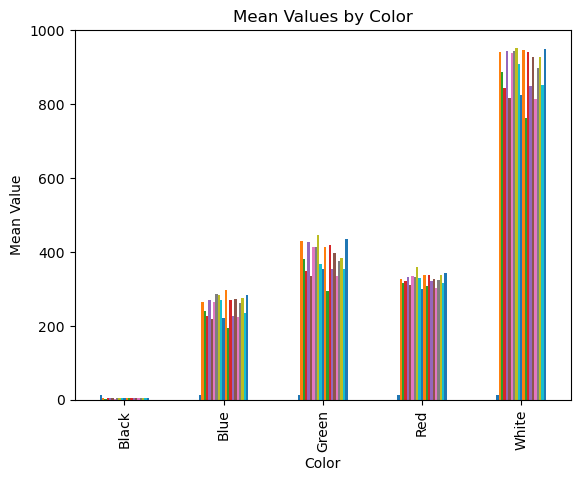

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Plot a bar chart with "Color" on the x-axis and the mean values on the y-axis
df.plot(x="Color", kind="bar", legend=None)

# Set labels and title
plt.xlabel("Color")
plt.ylabel("Mean Value")
plt.title("Mean Values by Color")

# Show the plot
plt.show()


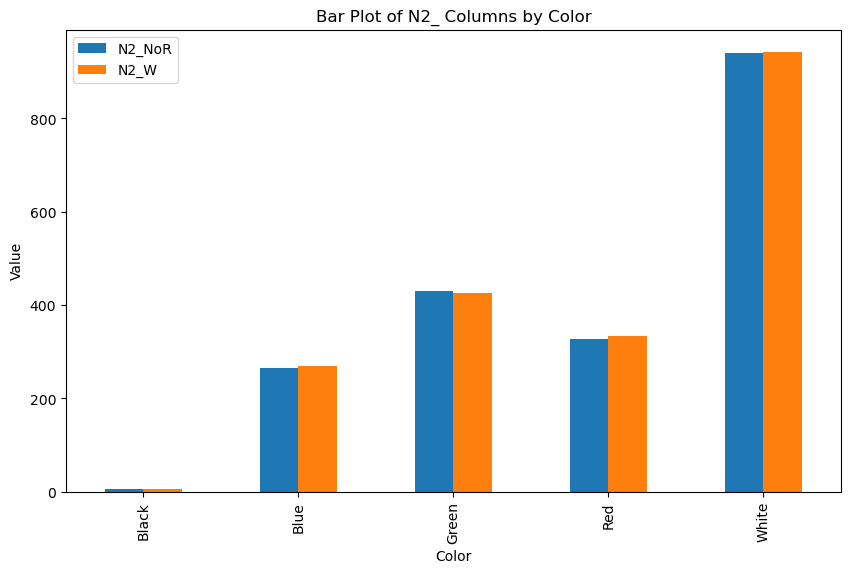

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Filter columns that start with "N2_"
n2_columns = [col for col in df.columns if col.startswith("N2_")]

# Set "Color" as the x-axis and "N2_" columns as the y-axis
df_plot = df[['Color'] + n2_columns]

# Set "Color" as the index for better plotting
df_plot = df_plot.set_index('Color')

# Create a bar plot
df_plot.plot(kind='bar', figsize=(10, 6))
plt.title("Bar Plot of N2_ Columns by Color")
plt.xlabel("Color")
plt.ylabel("Value")

# Show the plot
plt.show()



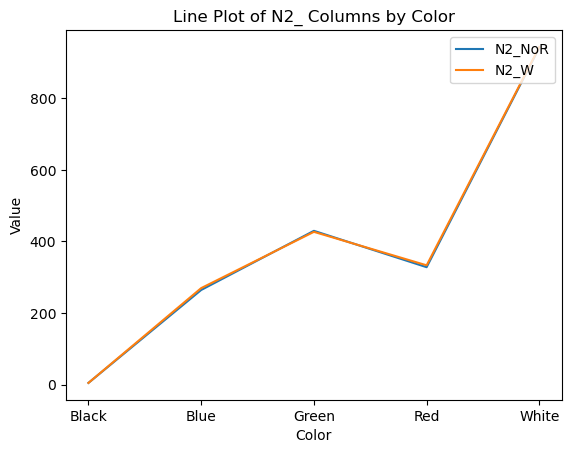

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Filter the columns starting with "N2_"
n2_columns = [col for col in df.columns if col.startswith("N2_")]

# Set "Color" column as the x-axis
x = df["Color"]

# Plot each "N2_" column as a separate line
for col in n2_columns:
    y = df[col]
    plt.plot(x, y, label=col)

# Customize the plot
plt.xlabel("Color")
plt.ylabel("Value")
plt.title("Line Plot of N2_ Columns by Color")
plt.legend(loc="upper right")

# Show the plot
plt.show()


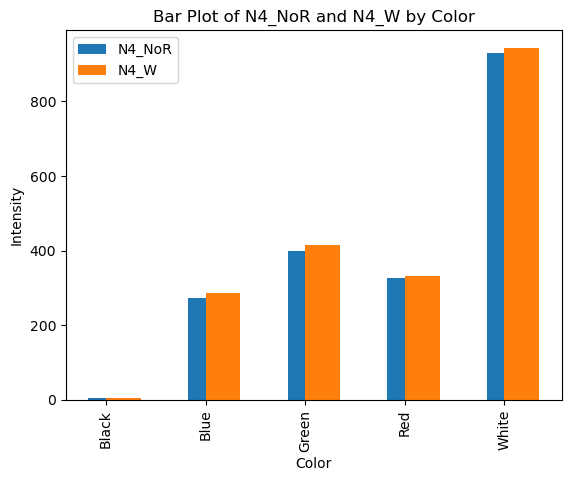

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Select the columns "Color," "N2_R," and "N2_WR"
df = df[["Color", "N4_NoR", "N4_W"]]

# Set "Color" column as the x-axis
x = df["Color"]

# Set the values of "N2_R" and "N2_WR" as the y-axis
y1 = df["N4_NoR"]
y2 = df["N4_W"]

# Define the width of the bars
bar_width = 0.35

# Set the x positions for the bars
x_indexes = range(len(x))

# Plot the "N2_R" and "N2_WR" values as side-by-side bars
plt.bar(x_indexes, y1, width=bar_width, label="N4_NoR", align="center")
plt.bar(x_indexes, y2, width=bar_width, label="N4_W", align="edge")

# Customize the plot
plt.xlabel("Color")
plt.ylabel("Intensity")
plt.title("Bar Plot of N4_NoR and N4_W by Color")
plt.xticks(x_indexes, x, rotation=90)
plt.legend()

# Show the plot
plt.show()



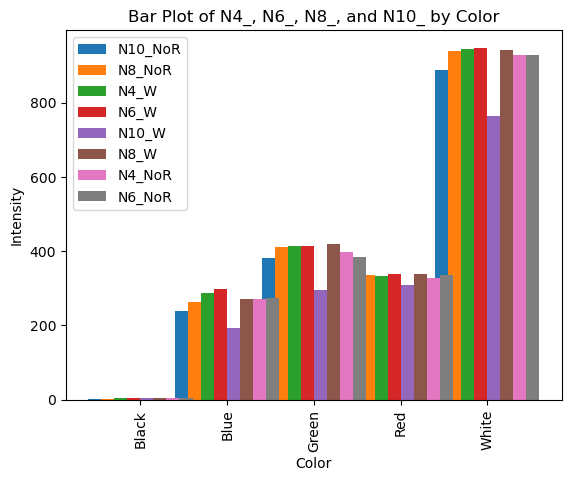

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Select the columns "Color," "N4_NoR," "N4_W," "N6_NoR," "N6_W," "N8_NoR," "N8_W," "N10_NoR," and "N10_W"
selected_columns = [col for col in df.columns if col.startswith("N4_") or col.startswith("N6_") or col.startswith("N8_") or col.startswith("N10_")]
df = df[["Color"] + selected_columns]

# Set "Color" column as the x-axis
x = df["Color"]

# Create a list of y-values for the selected columns
y_values = [df[col] for col in selected_columns]

# Define the width of the bars
bar_width = 0.15

# Set the x positions for the bars
x_indexes = range(len(x))

# Plot the values as side-by-side bars
for i, y in enumerate(y_values):
    plt.bar([x + i * bar_width for x in x_indexes], y, width=bar_width, label=selected_columns[i])

# Customize the plot
plt.xlabel("Color")
plt.ylabel("Intensity")
plt.title("Bar Plot of N4_, N6_, N8_, and N10_ by Color")
plt.xticks([x + bar_width * (len(selected_columns) - 1) / 2 for x in x_indexes], x, rotation=90)
plt.legend()

# Show the plot
plt.show()
